## Utilisation d'un PINN comme méthode d'inversion

In [93]:
import jax
import jax.numpy as jnp
import functools
import numpy as np
import optax
import matplotlib.pyplot as plt
from data_load import WaveguideBoundaryData

In [94]:
print(jax.devices())
#jax.config.update("jax_enable_x64", True)

[CudaDevice(id=0)]


**Data loading**

In [95]:
#Domaine Omega : [-1,1]x[0,0.6]
#conditions de neuman en y=0 et y=0.6
H = 0.6
L = 1

data_loader_left = WaveguideBoundaryData('data/pinn_boundary_left_barre_contrast20percent.csv')
data_loader_right = WaveguideBoundaryData('data/pinn_boundary_right_barre_contrast20percent.csv')

X_left, Y_left, U_re_left, U_im_left, freq = data_loader_left.get_training_data()
X_right, Y_right, U_re_right, U_im_right, _ = data_loader_right.get_training_data()

Y_left = Y_left[freq[0]]
Y_right = Y_right[freq[0]]

**Normalisation des outputs et inputs**

In [96]:
# x est déjà dans [-1,1]
#on passe y et u au bord dans [-1,1]

Y_norm = jnp.max(Y_left)
Y_left=2*Y_left/Y_norm - 1
Y_right=2*Y_right/Y_norm - 1

U_norm = {}
U_left_norm = {}
U_right_norm = {}

for f in freq:
    U_norm[f] = np.sqrt(jnp.max(np.concatenate((U_re_left[f]**2 + U_im_left[f]**2,U_re_right[f]**2 + U_im_right[f]**2))))
    U_re_left[f]/=U_norm[f]
    U_im_left[f]/=U_norm[f]
    U_re_right[f]/=U_norm[f]
    U_im_right[f]/=U_norm[f]
    U_left_norm[f] = jnp.stack([U_re_left[f],U_im_left[f]], axis=1)
    U_right_norm[f] = jnp.stack([U_re_right[f],U_im_right[f]], axis=1)

**Initialisation des paramètres**

In [97]:
key = jax.random.key(42)

#Initialisation des Fouriers Features
fmax = 200
c0 = 340
cmax = 1.5 * c0
cmin = 0.5 * c0
contrast = 1
N_modes = int(jnp.round(2*H*fmax/c0)) + 5
kmax = 2*jnp.pi*fmax/(contrast*340)
m = 64

msq_min = 1.0 / (cmax**2)
msq_max = 1.0 / (cmin**2)

key, subkey = jax.random.split(key)

B_base = jax.random.normal(subkey, (m, 2))

def gamma(x, y, sigma):
    x_phys = x * L 
    y_phys = (y + 1.0) * H / 2.0
    v_phys = jnp.array([x_phys, y_phys])
    B = B_base * sigma
    return jnp.concatenate([jnp.cos(B@v_phys),jnp.sin(B@v_phys)])

n_gauss_legendre = 20

y_gauss_legendre, w_gauss_legendre = np.polynomial.legendre.leggauss(n_gauss_legendre)

n_input = 2
n_layers_uv = [2*m, 64, 64, 64, 64, 2]
n_layers_m = [n_input, 64, 64, 1]

#Initialisation de Xavier

def init_layers(key, n_layers):
    layers = []
    for i in range(len(n_layers)-1):
        key, subkey = jax.random.split(key)
        W = jax.random.normal(subkey, (n_layers[i], n_layers[i+1])) * jnp.sqrt(2/(n_layers[i] + n_layers[i+1]))
        b = jnp.zeros(n_layers[i+1])
        layers.append({"W": W, "b": b})
    return layers, key


key, subkey_uv, subkey_m = jax.random.split(key, 3)
layers_uv, key = init_layers(subkey_uv, n_layers_uv)
layers_m, key = init_layers(subkey_m, n_layers_m)

params_uv = {
    'layers': layers_uv,
    'sigma': jnp.array([kmax, 0.0])
}

**Le Forward**

In [98]:
def forward_func(layers,X):
    n = len(layers)
    Z = X
    for i in range(n-1):
        Z = jax.nn.tanh(Z @ layers[i]["W"] + layers[i]["b"])
    Z = Z @ layers[-1]["W"] + layers[-1]["b"]
    return Z
 
def forward_params(layers,X):
    n = len(layers)
    Z = X
    for i in range(n-1):
        Z = jax.nn.tanh(Z @ layers[i]["W"] + layers[i]["b"])
    Z = msq_min + (msq_max-msq_min) * jax.nn.sigmoid(Z @ layers[-1]["W"] + layers[-1]["b"])
    return Z.squeeze()

**La loss function**

In [99]:
y_quad = (y_gauss_legendre + 1.0) * H / 2.0
w_quad = w_gauss_legendre * H / 2.0
n_modes = jnp.arange(N_modes)
a_n = jnp.sqrt(2/H) * jnp.ones(N_modes)
a_n = a_n.at[0].set(jnp.sqrt(1/H))
C_quad = a_n[:, None] * jnp.cos(n_modes[:, None] * jnp.pi * y_quad[None, :] / H)

def loss_fn(params_uv, layers_m, x, y, f, target_u_left, target_u_right, y_bnd_left, y_bnd_right, u_norm_val, weights, phase1=False):

    def uv(x,y):
        features = gamma(x, y, params_uv['sigma'])
        return forward_func(params_uv['layers'], features)
    
    def k2(x,y):
        if phase1:
            return (2*jnp.pi*f/c0)**2
        else:
            return (2*jnp.pi*f)**2*forward_params(layers_m, jnp.array([x, y]))
    
    def uv_x(x, y):
        return jax.jacfwd(uv, argnums=0)(x, y)/L
    
    def uv_y(x, y):
        return jax.jacfwd(uv, argnums=1)(x, y)*(2/H)

    def pde_residual(x, y):
        uv_xx = jax.jacfwd(jax.jacfwd(uv, argnums=0), argnums=0)(x, y) / L**2
        uv_yy = jax.jacfwd(jax.jacfwd(uv, argnums=1), argnums=1)(x, y)*(2/H)**2
        return uv_xx + uv_yy + k2(x,y)*uv(x,y)
    
    k0 = 2*jnp.pi*f/c0
    beta_n = jnp.sqrt(k0**2 - (n_modes*jnp.pi/H)**2 +0j)
    
    def compute_dtn_loss(x_bnd, y_data, sign, A_inc=None):
        uv_quad = jax.vmap(uv, in_axes=(None, 0))(x_bnd, y_gauss_legendre)
        U_quad_complex = uv_quad[:, 0] + 1j * uv_quad[:, 1]
        
        u_n = C_quad @ (w_quad * U_quad_complex)
        
        dtn_n = sign * 1j * beta_n * u_n
        if A_inc is not None:
            dtn_n = dtn_n + 2j * beta_n * A_inc
        
        def DtN_eval(y_eval):
            C_y = a_n * jnp.cos(n_modes * jnp.pi * (y_eval+1)/2)
            return C_y @ dtn_n
            
        dtn_pred_complex = jax.vmap(DtN_eval)(y_data)
        
        dtn_actual = jax.vmap(uv_x, in_axes=(None, 0))(x_bnd, y_data)
        dtn_actual_complex = dtn_actual[:, 0] + 1j * dtn_actual[:, 1]
        
        return jnp.mean(jnp.abs(dtn_pred_complex - dtn_actual_complex)**2)

    A_inc_left = jnp.zeros(N_modes, dtype=jnp.complex64)
    amplitude_incidente = jnp.exp(-1j * beta_n[0] * L) / u_norm_val
    A_inc_left = A_inc_left.at[0].set(amplitude_incidente)
    #residual
    vmap_pde_residual = jax.vmap(pde_residual, in_axes=(0, 0))
    pde_loss = jnp.mean(vmap_pde_residual(x, y)**2)
    #boundary conditions
    dtn_loss_left = compute_dtn_loss(-1.0, y, sign=-1, A_inc=A_inc_left)
    dtn_loss_right = compute_dtn_loss(1.0, y, sign=1, A_inc=None)
    neum_loss = jnp.mean(jax.vmap(uv_y, in_axes=(0, None))(x, 1.0)**2 + jax.vmap(uv_y, in_axes=(0, None))(x, -1.0)**2)
    bc_loss = neum_loss + dtn_loss_left + dtn_loss_right
    #data
    if phase1:
        data_loss = 0.0
    else:
        vmap_uv_y = jax.vmap(uv, (None,0))
        data_loss = jnp.mean((vmap_uv_y(-1.0,y_bnd_left) - target_u_left)**2)+jnp.mean((vmap_uv_y(1.0,y_bnd_right) - target_u_right)**2)

    total_loss = weights[0]*pde_loss + weights[1]*bc_loss + weights[2]*data_loss
    
    return total_loss, (pde_loss, bc_loss, data_loss)

**Le training**

In [100]:
lr_uv = 3e-4
lr_m = 3e-5

optimizer_uv = optax.chain(
    optax.adam(lr_uv)
)

optimizer_m = optax.chain(
    optax.adam(lr_m)
)

@functools.partial(jax.jit, static_argnames=('N',))
def train_step_forward(params_uv, layers_m, opt_state_uv, N, f_val, target_left, target_right, y_bnd_left, y_bnd_right, u_norm, current_weights, key):
    key, subkey1, subkey2 = jax.random.split(key, 3)
    x = jax.random.uniform(subkey1, (N,), minval=-1, maxval=1)
    y = jax.random.uniform(subkey2, (N,), minval=-1, maxval=1)
    
    (loss, aux), grads_uv = jax.value_and_grad(loss_fn, argnums=0, has_aux=True)(
        params_uv, layers_m, x, y, f_val, target_left, target_right,
        y_bnd_left, y_bnd_right, u_norm, current_weights, phase1=True
    )
    
    updates_uv, opt_state_uv = optimizer_uv.update(grads_uv, opt_state_uv, params_uv)
    params_uv = optax.apply_updates(params_uv, updates_uv)
    
    return params_uv, opt_state_uv, loss, aux, key

@functools.partial(jax.jit, static_argnames=('N',))
def train_step_inverse(params_uv, layers_m, opt_state_uv, opt_state_m, N, f_val, target_left, target_right, y_bnd_left, y_bnd_right, u_norm, current_weights, key):
    key, subkey1, subkey2 = jax.random.split(key, 3)
    x = jax.random.uniform(subkey1, (N,), minval=-1, maxval=1)
    y = jax.random.uniform(subkey2, (N,), minval=-1, maxval=1)
    
    (loss, aux), (grads_uv, grads_m) = jax.value_and_grad(loss_fn, argnums=(0,1), has_aux=True)(
        params_uv, layers_m, x, y, f_val, target_left, target_right,
        y_bnd_left, y_bnd_right, u_norm, current_weights, phase1=False
    )
    
    updates_uv, opt_state_uv = optimizer_uv.update(grads_uv, opt_state_uv, params_uv)
    params_uv = optax.apply_updates(params_uv, updates_uv)

    updates_m, opt_state_m = optimizer_m.update(grads_m, opt_state_m, layers_m)
    layers_m = optax.apply_updates(layers_m, updates_m)
    
    return params_uv, layers_m, opt_state_uv, opt_state_m, loss, aux, key

def train(params_uv, layers_m, N, max_steps_phase1, max_steps_phase2, freqs, eval_interval, loss_threshold, patience, key):

    loss_forward = []
    loss_inverse = []

    weights_phase1 = jnp.array([1.0, 1.0, 0.0])

    opt_state_m = optimizer_m.init(layers_m)
    
    for freq in freqs:
        print(f"\n--- f = {freq} Hz ---")

        opt_state_uv = optimizer_uv.init(params_uv)

        weights_phase1 = jnp.array([1.0, 1.0, 0.0])

        for step in range(round(max_steps_phase1)):

            params_uv, opt_state_uv, loss, aux, key = train_step_forward(
                        params_uv, layers_m, opt_state_uv, N, freq,
                        U_left_norm[freq], U_right_norm[freq],
                        Y_left, Y_right, U_norm[freq], weights_phase1, key
                    )

            if step % eval_interval == 0:
                    
                    pde_loss, bc_loss, data_loss = aux
                    loss_forward.append((pde_loss, bc_loss, data_loss))                    
                    print(f"Step {step} | pde {pde_loss:.2e} | dtn {bc_loss:.2e} | data {data_loss:.2e} | total {loss:.2e} | scales {params_uv['sigma']}")

        data_weight_schedule = optax.linear_schedule(init_value=1.0, end_value=100, transition_steps=max_steps_phase2//10)

        for step in range(max_steps_phase2):
            
            weights_phase2 = jnp.array([1.0, 10.0, data_weight_schedule(step)])
            params_uv, layers_m, opt_state_uv, opt_state_m, loss, aux, key = train_step_inverse(
                params_uv, layers_m, opt_state_uv, opt_state_m, N, freq,
                U_left_norm[freq], U_right_norm[freq],
                Y_left, Y_right, U_norm[freq], weights_phase2, key
            )
            
            if step % eval_interval == 0:
                    
                    pde_loss, bc_loss, data_loss = aux
                    loss_inverse.append((pde_loss, bc_loss, data_loss))
                    print(f"Step {step} | pde {pde_loss:.2e} | dtn {bc_loss:.2e} | data {data_loss:.2e} | total {loss:.2e} | scales {params_uv['sigma']}")

                
    return params_uv, layers_m, key, loss_forward, loss_inverse

**La phase d'entrainement**

In [101]:
eval = 50
N = 1000
loss_threshold = 1e-4
patience = 5
eval_interval = 1000
max_step_phase1 = 10000
max_step_phase2 = 30000

freq = np.array([200.0])

key, subkey = jax.random.split(key)
params_uv, layers_m, key, loss_forward, loss_inverse = train(params_uv, layers_m, N, max_step_phase1, max_step_phase2, freq, eval_interval, loss_threshold, patience, key)


--- f = 200.0 Hz ---
Step 0 | pde 7.14e+01 | dtn 1.95e+02 | data 0.00e+00 | total 2.67e+02 | scales [3.6956913e+00 2.9999801e-04]
Step 1000 | pde 1.22e-03 | dtn 2.15e-05 | data 0.00e+00 | total 1.24e-03 | scales [3.6855872e+00 6.9762283e-04]
Step 2000 | pde 2.55e-04 | dtn 2.63e-05 | data 0.00e+00 | total 2.82e-04 | scales [3.6853344e+00 4.0047707e-06]
Step 3000 | pde 2.92e-04 | dtn 2.77e-05 | data 0.00e+00 | total 3.20e-04 | scales [3.6851683e+00 5.7172788e-06]
Step 4000 | pde 2.02e-03 | dtn 3.37e-04 | data 0.00e+00 | total 2.36e-03 | scales [ 3.6847763e+00 -8.6079790e-06]
Step 5000 | pde 1.13e-03 | dtn 6.32e-04 | data 0.00e+00 | total 1.76e-03 | scales [3.6839595e+00 2.5781832e-05]
Step 6000 | pde 3.66e-04 | dtn 5.96e-05 | data 0.00e+00 | total 4.26e-04 | scales [ 3.6829376e+00 -6.5353393e-06]
Step 7000 | pde 2.10e-03 | dtn 6.36e-04 | data 0.00e+00 | total 2.74e-03 | scales [ 3.6818841e+00 -2.6692811e-05]
Step 8000 | pde 1.32e-03 | dtn 5.37e-04 | data 0.00e+00 | total 1.86e-03 | scal

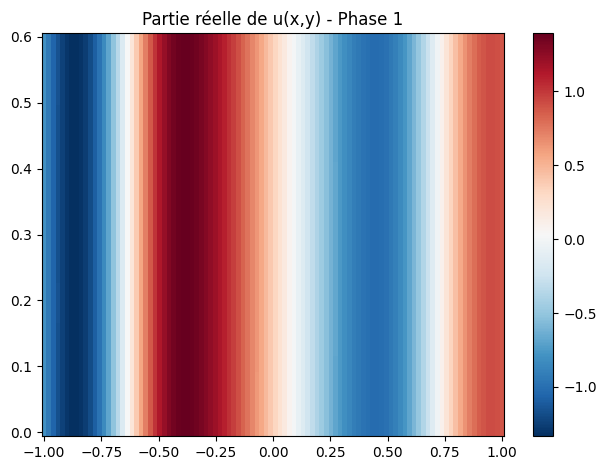

In [102]:
def u_real(x,y):
    features = gamma(x, y, params_uv['sigma']) 
    return forward_func(params_uv['layers'], features)[0] 

x = np.linspace(-1, 1, 100)
y = np.linspace(0, 0.6, 50)

u_grid = jax.vmap(jax.vmap(u_real, in_axes=(0, None)), in_axes=(None, 0))(x, 2*y/H - 1)

plt.pcolormesh(x, y, u_grid, cmap='RdBu_r')
plt.colorbar()
plt.title("Partie réelle de u(x,y) - Phase 1")
plt.tight_layout()
plt.show()

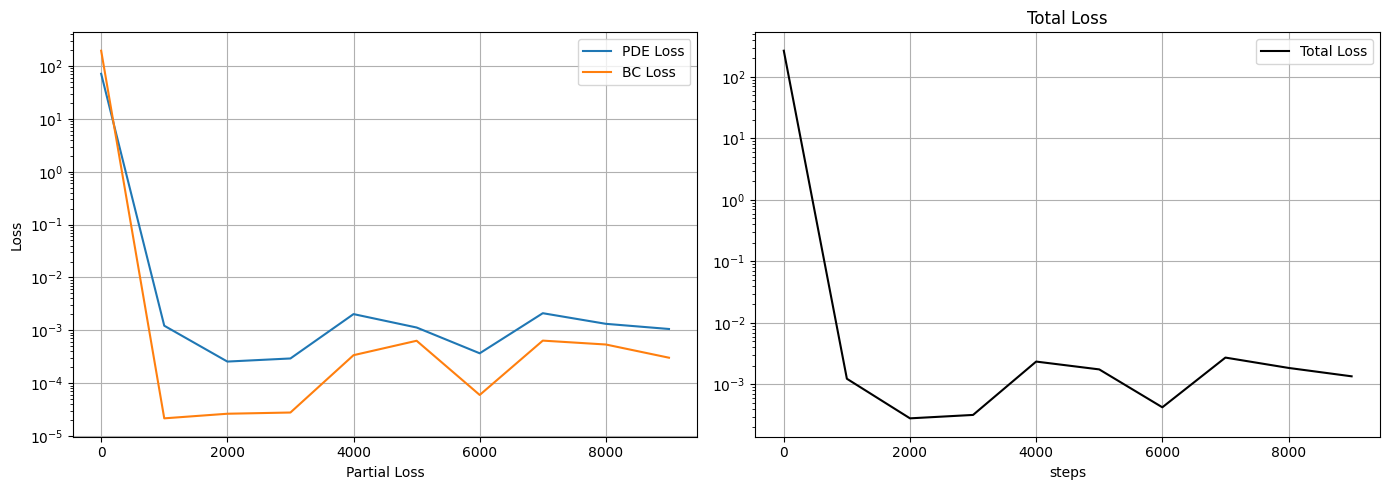

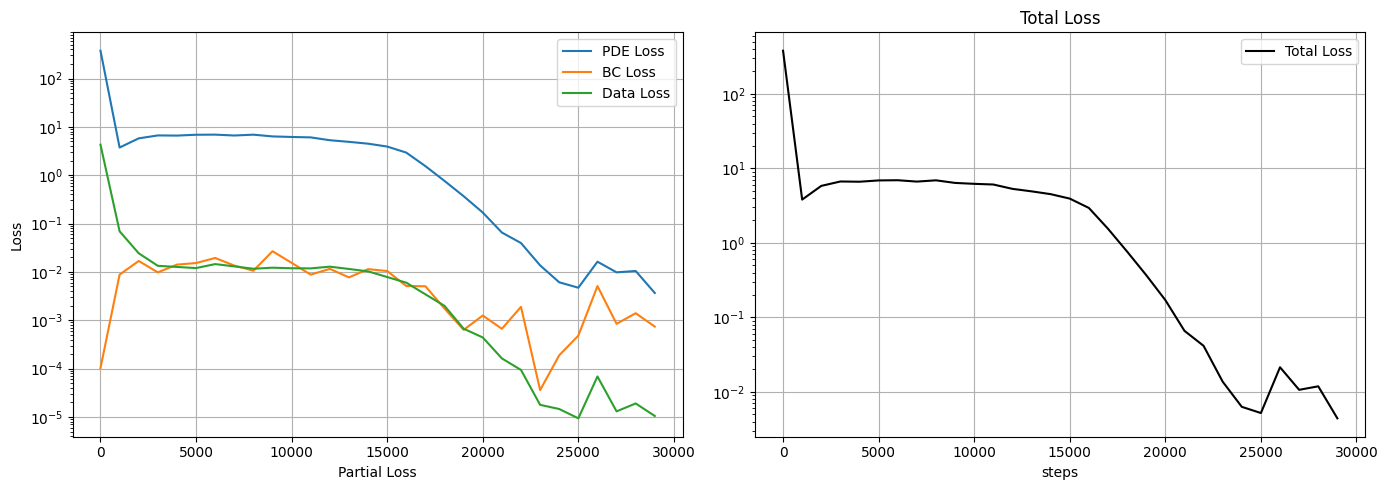

In [103]:
loss_forward_arr = np.array(loss_forward)
pde_losses = loss_forward_arr[:, 0]
dtn_losses = loss_forward_arr[:, 1]
total_losses = pde_losses + dtn_losses

eval_interval_plot = eval_interval

x_axis = eval_interval_plot * np.arange(len(loss_forward))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.semilogy(x_axis, pde_losses, label="PDE Loss")
ax1.semilogy(x_axis, dtn_losses, label="BC Loss")

ax2.semilogy(x_axis, total_losses, label="Total Loss", color='black')

ax1.set_xlabel("Partial Loss")
ax1.set_ylabel("Loss")
ax1.legend(loc="upper right")
ax1.grid(True)

ax2.set_title("Total Loss")
ax2.set_xlabel("steps")
ax2.legend(loc="upper right")
ax2.grid(True)

plt.tight_layout()
plt.show()

loss_inverse_arr = np.array(loss_inverse)
pde_losses = loss_inverse_arr[:,0]
dtn_losses = loss_inverse_arr[:,1]
data_losses = loss_inverse_arr[:,2]
total_losses = pde_losses + dtn_losses + data_losses

eval_interval_plot = eval_interval

x_axis = eval_interval_plot * np.arange(len(loss_inverse_arr))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.semilogy(x_axis, pde_losses, label="PDE Loss")
ax1.semilogy(x_axis, dtn_losses, label="BC Loss")
ax1.semilogy(x_axis, data_losses, label="Data Loss")

ax2.semilogy(x_axis, total_losses, label="Total Loss", color='black')

ax1.set_xlabel("Partial Loss")
ax1.set_ylabel("Loss")
ax1.legend(loc="upper right")
ax1.grid(True)

ax2.set_title("Total Loss")
ax2.set_xlabel("steps")
ax2.legend(loc="upper right")
ax2.grid(True)

plt.tight_layout()
plt.show()

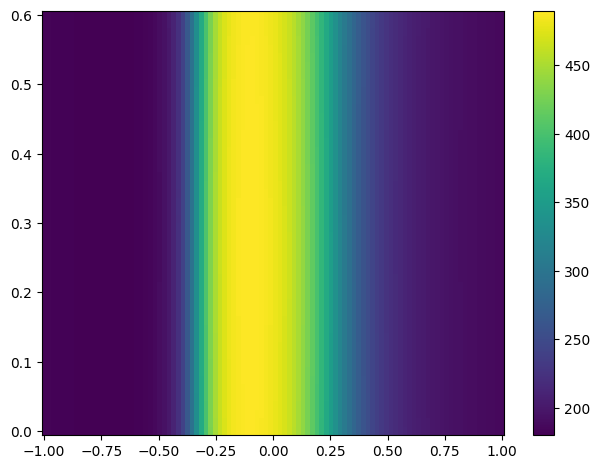

In [104]:
def c(x,y):
    return 1/jnp.sqrt(forward_params(layers_m, jnp.array([x, y])))

x = np.linspace(-1,1,100)
y = np.linspace(0,0.6,50)

c_grid = jax.vmap(jax.vmap(c, in_axes=(0, None)), in_axes=(None, 0))(x,2*y/H-1)

plt.pcolormesh(x, y, c_grid)
plt.colorbar()
plt.tight_layout()
plt.savefig('fig/2D_Wave_guide_c_map.pdf')
plt.show()